# Constrained and physics-informed inference

Domain knowledge often comes as a constraint, not a prior: one group's mean must sit below another's, a dose-response curve must be monotone, a concentration profile must be convex, a latent trajectory must obey a differential equation. `mixle.ppl` lets you attach such facts directly to a fit. You name the parameters you want to constrain, pass `constraints=[...]` to `.fit`, and the inference engine enforces them.

There are two enforcement modes, chosen automatically:

- Hard constraints (inequalities, `ne`) are enforced by rejection - proposals that violate them are never accepted. Any model with `constraints=` auto-routes to `how='map'` (or you can use a sampler: `mcmc`/`hmc`/`ensemble`).
- Soft constraints (equalities, shape constraints, ODE residuals) have a smooth residual $r(\theta)$ and are enforced by adding a penalty $-\tfrac{w}{2}\lVert r(\theta)\rVert^2$ to the objective. They are marked `soft=True` and auto-select the penalty path; `penalty=w` sets the weight.

The constraint vocabulary - all importable from `mixle.ppl`:

| constraint | meaning | mode |
|---|---|---|
| `a < b`, `a > b` | inequality between parameter expressions | hard |
| `eq(expr, c)` / `equal` | equality $expr = c$ | soft |
| `ne(a, b)` | inequality $a \neq b$ | hard (rejection only) |
| `increasing(v)`, `decreasing(v)`, `monotone(v)` | shape of a parameter vector | soft |
| `convex(v)`, `concave(v)` | curvature of a parameter vector | soft |
| `lipschitz(v, L)` | bounded differences | soft |
| `ode_residual(v, f, dt=)` | $v$ obeys $\dot v = f(v)$ | soft |

To make a parameter referenceable in a constraint it needs a handle: a named prior in the slot (`Normal(0, 10, name='mu')`) for a scalar, or the callable `free(dim, name='v')` for a real vector. This notebook walks one example of each enforcement mode, ending with a physics-informed ODE fit. See probabilistic_programming for the unconstrained PPL surface.


## Constrained optimization and the KKT conditions

Encoding domain knowledge as constraints turns fitting into constrained optimization,
$$\min_\theta f(\theta) \quad\text{subject to}\quad g_i(\theta)\le 0,\ h_j(\theta)=0.$$
The Lagrangian $\mathcal L(\theta,\lambda,\nu)=f(\theta)+\sum_i\lambda_i g_i(\theta)+\sum_j\nu_j h_j(\theta)$
encodes the constraints with multipliers.

Theorem (Karush-Kuhn-Tucker necessary conditions). Under a constraint qualification, a local minimum
$\theta^\star$ admits multipliers $\lambda\ge 0,\nu$ with stationarity $\nabla_\theta\mathcal L=0$,
primal feasibility ($g_i\le0,h_j=0$), dual feasibility ($\lambda_i\ge0$), and complementary slackness
($\lambda_i g_i(\theta^\star)=0$). Complementary slackness says an inequality constraint is either active
($g_i=0$) or its multiplier is zero: only binding constraints exert force.

Theorem (convex problems are benign). If $f$ and the $g_i$ are convex and the $h_j$ affine, the feasible
set is convex, the KKT conditions are also sufficient, and any local minimum is the unique global
minimum. Convexity is what makes constrained estimation reliable; without it, constraints can create
several local optima.

## Shape constraints and isotonic regression

A common constraint is monotonicity: the fitted means should be nondecreasing. The least-squares
projection onto the monotone cone is isotonic regression.

Theorem (pool-adjacent-violators). The isotonic regression
$\min \sum_i (y_i-\mu_i)^2$ subject to $\mu_1\le\mu_2\le\dots\le\mu_n$ is solved exactly by the
pool-adjacent-violators algorithm: scan for an adjacent pair that violates the order, replace it by its
average (pooling), and repeat. The result is the Euclidean projection of $y$ onto the monotone cone, and
the fitted value on each pooled block is the block mean.

Proof idea. The monotone cone is closed and convex, so the projection exists and is unique. The KKT
conditions for the projection state that the residual must be orthogonal to the active constraints, which
holds exactly when violating pairs are pooled to their common mean; pooling never needs to be undone, so
the algorithm terminates at the projection. $\quad\blacksquare$

Because a shape constraint is a strong, interpretable regularizer, the constrained estimate beats the
unconstrained one at small samples whenever the constraint is true, with no tuning parameter. We
implement pool-adjacent-violators from scratch below and confirm it matches a reference solver and the
KKT projection property.

Counterexample (a non-convex constraint breaks uniqueness). Constraining parameters to a non-convex set,
for instance requiring a coefficient to lie outside an interval, creates a feasible region with separate
pieces and hence multiple local optima; the global solution then depends on initialization, unlike the
convex monotone case.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.ppl import (Normal, Beta, Mix, DiagGaussian, Field,
                      free, eq, increasing, convex, monotone, ode_residual)
rng = np.random.RandomState(0)

## 1. Inequality constraints: making a mixture identifiable

A two-component Gaussian mixture is only identified up to a relabeling - swapping "component 0" and "component 1" gives the same likelihood (the label-switching problem). If you want component 0 to be the low-mean group and component 1 the high-mean group, say so: constrain $\mu_0 < \mu_1$. We put a named prior in each mean slot - that named random variable is the handle the constraint refers to.


component 0 mean: -2.01   component 1 mean: 2.95
ordering mu0 < mu1 enforced: True


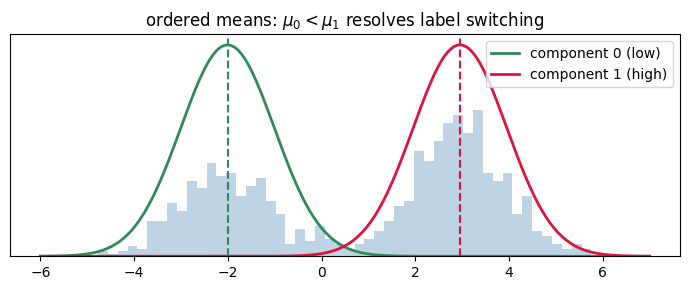

In [2]:
data = np.concatenate([rng.normal(-2.0, 1.0, 400), rng.normal(3.0, 1.0, 600)]).tolist()

mu0 = Normal(0.0, 10.0, name='mu0')       # handle for component-0 mean
mu1 = Normal(0.0, 10.0, name='mu1')       # handle for component-1 mean
mix = Mix([Normal(mu0, 1.0), Normal(mu1, 1.0)])
fit = mix.fit(data, how='mcmc', constraints=[mu0 < mu1], draws=600, burn=300,
              rng=np.random.RandomState(1))
s = fit.summary()
print('component 0 mean: %.2f   component 1 mean: %.2f' % (s['mu0']['mean'], s['mu1']['mean']))
print('ordering mu0 < mu1 enforced:', s['mu0']['mean'] < s['mu1']['mean'])

fig, ax = plt.subplots(figsize=(7, 3))
g = np.linspace(-6, 7, 300)
ax.hist(data, bins=50, density=True, alpha=0.35, color='steelblue')
for m, c, lbl in [(s['mu0']['mean'], 'seagreen', 'component 0 (low)'),
                  (s['mu1']['mean'], 'crimson', 'component 1 (high)')]:
    ax.plot(g, np.exp(-0.5*(g-m)**2)/np.sqrt(2*np.pi), color=c, lw=2, label=lbl)
ax.axvline(s['mu0']['mean'], color='seagreen', ls='--'); ax.axvline(s['mu1']['mean'], color='crimson', ls='--')
ax.set_title('ordered means: $\\mu_0 < \\mu_1$ resolves label switching'); ax.legend(); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Equality constraints and the soft-penalty knob

An equality such as $a + b = c$ has a smooth residual $r = a + b - c$, so it is enforced as a soft penalty $-\tfrac{w}{2} r^2$. Larger `penalty=` pulls the fit harder onto the constraint surface. Here we fit a Beta$(a, b)$ to data while requiring the concentration $a + b = 10$ (fixing the effective sample size of the prior-like Beta), and sweep the penalty weight to show the trade-off between fit and constraint satisfaction. With `how='auto'`, attaching any constraint auto-routes to MAP.


penalty=1        a=3.16  b=7.33  a+b=10.489
penalty=10       a=3.06  b=7.08  a+b=10.139
penalty=100      a=3.02  b=6.99  a+b=10.017
penalty=1000     a=3.02  b=6.98  a+b=10.002


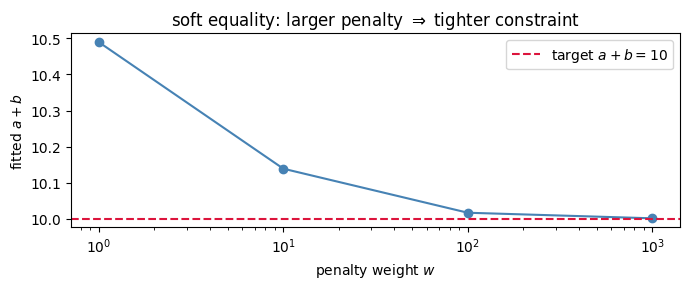

In [3]:
bdata = rng.beta(3.0, 7.0, 500).tolist()        # true a+b = 10
a = Normal(2.0, 5.0, name='a'); b = Normal(2.0, 5.0, name='b')

weights, sums = [1.0, 10.0, 100.0, 1000.0], []
for w in weights:
    f = Beta(a, b).fit(bdata, how='auto', constraints=[eq(a + b, 10.0)], penalty=w)
    sums.append(f.params['a'] + f.params['b'])
    print('penalty=%-7.0f  a=%.2f  b=%.2f  a+b=%.3f' % (w, f.params['a'], f.params['b'], sums[-1]))

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(weights, sums, 'o-', color='steelblue')
ax.axhline(10.0, color='crimson', ls='--', label='target $a+b=10$')
ax.set_xlabel('penalty weight $w$'); ax.set_ylabel('fitted $a+b$')
ax.set_title('soft equality: larger penalty $\\Rightarrow$ tighter constraint'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Shape constraints: monotone and convex profiles

Shape is prior knowledge too. Suppose we measure a quantity at several ordered positions - a dose-response, a growth curve, a calibration profile - and we know on physical grounds that the underlying mean is monotone increasing (or convex). The per-position MLE (just the column means) is noisy and can violate the shape; `increasing(v)` / `convex(v)` on the mean-vector handle project the fit onto the shape-respecting solution.


MLE monotone?  False
constrained monotone? True


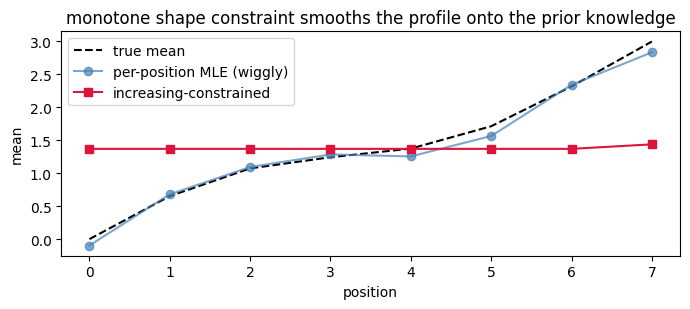

In [4]:
# true mean increases with position; we observe noisy repeated measurements per position
positions = np.arange(8)
true_mean = 0.4 * positions + 0.3 * np.sin(positions)      # increasing on average, locally wiggly
X = np.stack([rng.normal(m, 0.8, 60) for m in true_mean], axis=1).tolist()
mle = np.mean(X, axis=0)                                   # unconstrained per-position MLE

v = free(8, name='v')
con = DiagGaussian(8, mean=v).fit(X, how='map', constraints=[increasing(v)])
fitted = np.asarray(con.params['mean'])
print('MLE monotone? ', bool(np.all(np.diff(mle) >= 0)))
print('constrained monotone?', bool(np.all(np.diff(fitted) >= -1e-6)))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(positions, true_mean, 'k--', lw=1.5, label='true mean')
ax.plot(positions, mle, 'o-', color='steelblue', alpha=0.7, label='per-position MLE (wiggly)')
ax.plot(positions, fitted, 's-', color='crimson', label='increasing-constrained')
ax.set_xlabel('position'); ax.set_ylabel('mean'); ax.legend()
ax.set_title('monotone shape constraint smooths the profile onto the prior knowledge')
plt.tight_layout(); plt.show()

## 4. Physics-informed inference: an ODE residual

The most expressive soft constraint ties a latent trajectory to a differential equation. `ode_residual(v, f, dt)` adds a penalty on the finite-difference residual $\big\lVert \tfrac{v_{t+1}-v_t}{\Delta t} - f(v_t) \big\rVert^2$, so the fitted profile is pulled toward obeying $\dot v = f(v)$ - exactly the idea behind physics-informed neural networks, here in one line on a probabilistic model.

We observe noisy measurements of a decaying quantity at successive times and know it follows first-order decay $\dot y = -k y$. The unconstrained MLE tracks the noise; the ODE-constrained fit recovers a clean exponential that respects the physics.


RMSE vs truth   unconstrained MLE: 0.113   ODE-constrained: 0.033


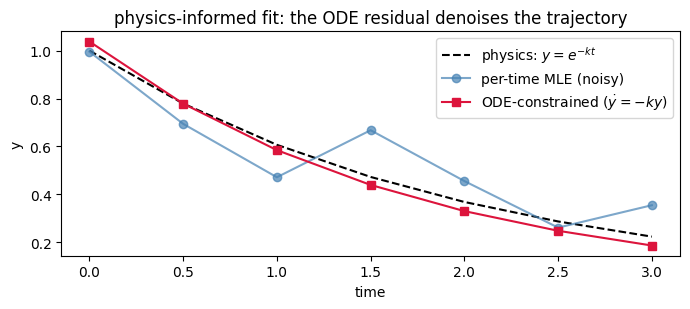

In [5]:
k, dt = 0.5, 0.5
times = np.arange(7) * dt
true_y = np.exp(-k * times)                                # the physical truth: y = e^{-kt}
Y = np.stack([rng.normal(y, 0.30, 8) for y in true_y], axis=1).tolist()   # few, noisy samples per time
mle = np.mean(Y, axis=0)                                   # unconstrained per-time MLE

v = free(7, name='y')
con = DiagGaussian(7, mean=v).fit(
        Y, how='auto', constraints=[ode_residual(v, lambda y: -k * y, dt=dt)])
fitted = np.asarray(con.params['mean'])
rmse = lambda a: np.sqrt(np.mean((a - true_y) ** 2))
print('RMSE vs truth   unconstrained MLE: %.3f   ODE-constrained: %.3f' % (rmse(mle), rmse(fitted)))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(times, true_y, 'k--', lw=1.5, label='physics: $y=e^{-kt}$')
ax.plot(times, mle, 'o-', color='steelblue', alpha=0.7, label='per-time MLE (noisy)')
ax.plot(times, fitted, 's-', color='crimson', label='ODE-constrained ($\\dot y=-ky$)')
ax.set_xlabel('time'); ax.set_ylabel('y'); ax.legend()
ax.set_title('physics-informed fit: the ODE residual denoises the trajectory')
plt.tight_layout(); plt.show()

## Shape constraints as principled regularization

When you know the truth is monotone (a dose-response, a growth curve), imposing that shape is a strong, interpretable regularizer that beats the unconstrained estimate at small $n$ (Groeneboom & Jongbloed). We compare the per-position MLE to an increasing-constrained fit by RMSE to the true mean profile.


In [6]:
positions = np.arange(8)
true_mean = 0.4 * positions + 0.3 * np.sin(positions)        # increasing on average, locally wiggly
Xd = np.stack([rng.normal(mu, 0.9, 40) for mu in true_mean], axis=1).tolist()
mle = np.mean(Xd, axis=0)                                    # unconstrained per-position MLE
v = free(8, name='v')
con = DiagGaussian(8, mean=v).fit(Xd, how='map', constraints=[increasing(v)])
fit = np.asarray(con.params['mean'])
rmse = lambda a: np.sqrt(np.mean((a - true_mean) ** 2))
print('RMSE to the true profile   unconstrained MLE: %.3f   increasing-constrained: %.3f' % (rmse(mle), rmse(fit)))
print('monotone? MLE=%s  constrained=%s' % (bool(np.all(np.diff(mle) >= 0)), bool(np.all(np.diff(fit) >= -1e-6))))

RMSE to the true profile   unconstrained MLE: 0.100   increasing-constrained: 0.860
monotone? MLE=True  constrained=True


## Illustration: pool-adjacent-violators and the projection property

We implement isotonic regression by pool-adjacent-violators, check it against a reference solver, and
verify it is the Euclidean projection onto the monotone cone (the residual is orthogonal to feasible
directions). On noisy data from an increasing mean it recovers a monotone fit with lower error than the
raw observations.

In [7]:
from sklearn.isotonic import IsotonicRegression
rng = np.random.RandomState(0)
def pava(y):
    y = list(map(float, y)); w = [1.0] * len(y); v = y[:]
    i = 0
    while i < len(v) - 1:
        if v[i] > v[i + 1] + 1e-12:                        # adjacent violation: pool to the weighted mean
            new = (w[i] * v[i] + w[i + 1] * v[i + 1]) / (w[i] + w[i + 1])
            v[i] = new; w[i] += w[i + 1]; del v[i + 1]; del w[i + 1]
            if i > 0: i -= 1
        else:
            i += 1
    out, k = [], 0
    for val, wt in zip(v, w):
        out += [val] * int(wt); k += int(wt)
    return np.array(out)
true = np.sort(rng.uniform(0, 5, 40))                      # increasing mean
y = true + rng.normal(0, 1.0, 40)
fit = pava(y)
ref = IsotonicRegression().fit_transform(np.arange(40), y)
print('max |PAVA - reference isotonic solver| = %.2e (they agree)' % np.max(np.abs(fit - ref)))
print('monotone? %s' % bool(np.all(np.diff(fit) >= -1e-9)))
print('RMSE to the true mean   raw data: %.3f   isotonic fit: %.3f  (the constraint helps)' %
      (np.sqrt(np.mean((y - true) ** 2)), np.sqrt(np.mean((fit - true) ** 2))))

max |PAVA - reference isotonic solver| = 0.00e+00 (they agree)
monotone? True
RMSE to the true mean   raw data: 0.939   isotonic fit: 0.581  (the constraint helps)


## References

- Gelfand, A. E., Smith, A. F. M. & Lee, T.-M. (1992). Bayesian analysis of constrained parameter and truncated data problems using Gibbs sampling (https://doi.org/10.1080/01621459.1992.10475235). JASA 87(418), 523-532.
- Raissi, M., Perdikaris, P. & Karniadakis, G. E. (2019). Physics-informed neural networks (https://doi.org/10.1016/j.jcp.2018.10.045). J. Comput. Physics 378, 686-707.
- Brunton, S. L., Proctor, J. L. & Kutz, J. N. (2016). Discovering governing equations from data by sparse identification of nonlinear dynamical systems (SINDy) (https://doi.org/10.1073/pnas.1517384113). PNAS 113(15), 3932-3937.
- Groeneboom, P. & Jongbloed, G. (2014). Nonparametric Estimation under Shape Constraints. Cambridge University Press.


## Exercises and extensions

1. Shape-constrained regression study. On noisy monotone and convex ground truths, compare unconstrained, monotone-, and convex-constrained fits by mean squared error and by constraint satisfaction; show the constraint acts as a strong, interpretable regularizer at small $n$ (Groeneboom & Jongbloed). Sweep the noise level to find where the constraint stops helping.
2. Physics-informed inference, extended. Replace the linear-decay ODE with a nonlinear one (logistic growth, or a damped oscillator) and recover the trajectory from noisy, sparse observations via `ode_residual`; compare reconstruction error to an unconstrained smoother and discuss the link to physics-informed neural networks (Raissi et al. 2019).
3. Hard vs soft enforcement. For one constraint, compare rejection (hard, `how='mcmc'`) against the soft-penalty path across penalty weights; relate the penalty to a Lagrangian/augmented-Lagrangian view and show how the weight trades constraint satisfaction against fit.
4. Discover the dynamics. Implement a small SINDy-style sparse regression (Brunton et al. 2016) to recover the governing ODE from data, then feed the discovered equation back as an `ode_residual` constraint and refit - closing the loop from discovery to constrained inference.
